# Differential Expression and Biological Findings

In [1]:
import scanpy as sc
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import os
os.makedirs("../figures", exist_ok=True)
os.makedirs("../results", exist_ok=True)

adata_qc = sc.read_h5ad("../results/adata_qc_clustered_annotated.h5ad")

# 01 - Global Infection Response in DMSO Control

To isolate the effect of infection, infected and uninfected cells are compared
within each timepoint under DMSO control.

## 01A - Early Infection Response (4h, DMSO)

In [2]:
# Create 4h DMSO subset
adata_4h = adata_qc[
    adata_qc.obs["ID"].isin([
        "4h_infected_DMSO",
        "4h_uninfected_DMSO"
    ])
].copy()

In [3]:
# Check groups
adata_4h.obs["ID"].value_counts()

ID
4h_uninfected_DMSO    250
4h_infected_DMSO      126
Name: count, dtype: int64

In [4]:
# Create infection label
adata_4h.obs["infection"] = adata_4h.obs["ID"].apply(
    lambda x: "uninfected" if "uninfected" in x else "infected"
)

In [5]:
# Check groups
adata_4h.obs["infection"].value_counts()

infection
uninfected    250
infected      126
Name: count, dtype: int64

In [6]:
# Run DE
sc.tl.rank_genes_groups(
    adata_4h,
    groupby="infection",
    method="wilcoxon"
)

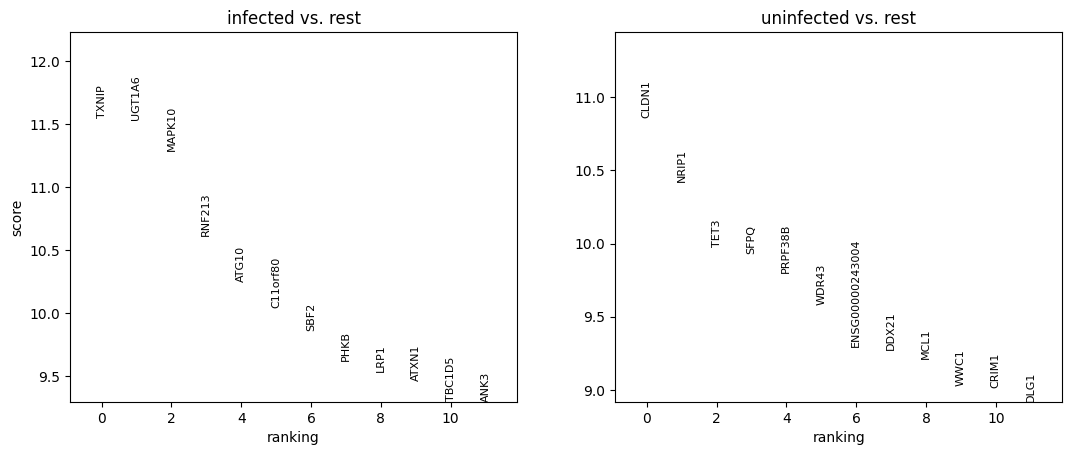

In [7]:
# Plot ranked genes
sc.pl.rank_genes_groups(
    adata_4h,
    n_genes=12,
    sharey=False
)

In [8]:
# Extract top genes
top_infected_4h = pd.DataFrame(
    adata_4h.uns["rank_genes_groups"]["names"]
)["infected"].head(6).tolist()

top_uninfected_4h = pd.DataFrame(
    adata_4h.uns["rank_genes_groups"]["names"]
)["uninfected"].head(6).tolist()

top_genes_4h = list(dict.fromkeys(top_infected_4h + top_uninfected_4h))

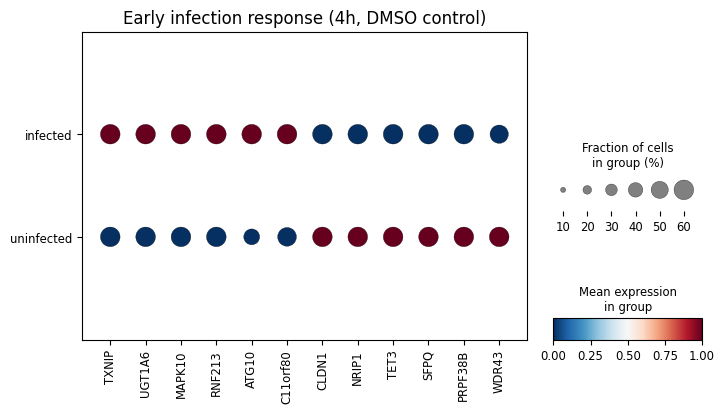

In [9]:
# Plot dotplot
sc.pl.dotplot(
    adata_4h,
    var_names=top_genes_4h,
    groupby="infection",
    standard_scale="var",
    cmap="RdBu_r",
    dot_max=0.6,
    figsize=(8, 4),
    title="Early infection response (4h, DMSO control)",
    show=False
)

plt.savefig("../figures/Figure_09_section_01A_4h_infection_dmso.png", dpi=300, bbox_inches="tight")
plt.show()

## 01B - Late Infection Response (24h, DMSO)

In [10]:
# Create 24h DMSO subset
adata_24h = adata_qc[
    adata_qc.obs["ID"].isin([
        "24h_infected_DMSO",
        "24h_uninfected_DMSO"
    ])
].copy()

In [11]:
# Check groups
adata_24h.obs["ID"].value_counts()

ID
24h_infected_DMSO      8506
24h_uninfected_DMSO    1373
Name: count, dtype: int64

In [12]:
# Create infection label
adata_24h.obs["infection"] = adata_24h.obs["ID"].apply(
    lambda x: "uninfected" if "uninfected" in x else "infected"
)

In [13]:
# Check groups
adata_24h.obs["infection"].value_counts()

infection
infected      8506
uninfected    1373
Name: count, dtype: int64

In [14]:
# Run DE
sc.tl.rank_genes_groups(
    adata_24h,
    groupby="infection",
    method="wilcoxon"
)

In [15]:
# Extract top genes
top_infected_24h = pd.DataFrame(
    adata_24h.uns["rank_genes_groups"]["names"]
)["infected"].head(6).tolist()

top_uninfected_24h = pd.DataFrame(
    adata_24h.uns["rank_genes_groups"]["names"]
)["uninfected"].head(6).tolist()

top_genes_24h = list(dict.fromkeys(top_infected_24h + top_uninfected_24h))

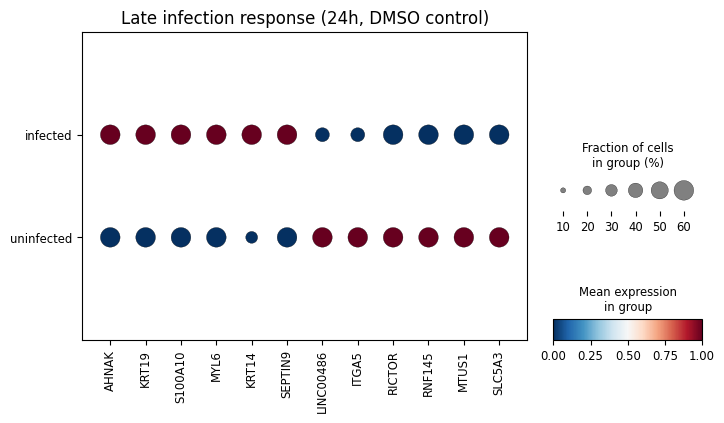

In [16]:
# Plot dotplot
sc.pl.dotplot(
    adata_24h,
    var_names=top_genes_24h,
    groupby="infection",
    standard_scale="var",
    cmap="RdBu_r",
    dot_max=0.6,
    figsize=(8, 4),
    title="Late infection response (24h, DMSO control)",
    show=False
)

plt.savefig("../figures/Figure_10_section_01B_24h_infection_dmso.png", dpi=300, bbox_inches="tight")
plt.show()

# 02 - QC Check on Uninfected Cells Across Time

Uninfected cells at 4h and 24h are compared to assess whether timepoint
strongly affects cell-state composition.

In [17]:
# Create uninfected subset
adata_uninf = adata_qc[
    adata_qc.obs["ID"].isin([
        "4h_uninfected_DMSO",
        "24h_uninfected_DMSO"
    ])
].copy()

In [18]:
# Check groups
adata_uninf.obs["ID"].value_counts()

ID
24h_uninfected_DMSO    1373
4h_uninfected_DMSO      250
Name: count, dtype: int64

In [19]:
# Create time label
adata_uninf.obs["time"] = adata_uninf.obs["ID"].apply(
    lambda x: "24h" if "24h" in x else "4h"
)

In [20]:
# Check time groups
adata_uninf.obs["time"].value_counts()

time
24h    1373
4h      250
Name: count, dtype: int64

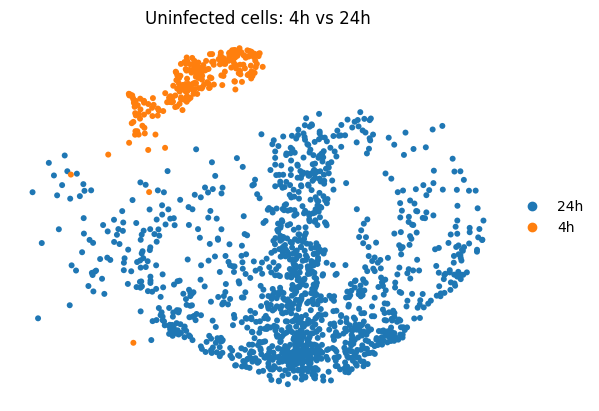

In [21]:
# Plot time on UMAP
sc.pl.umap(
    adata_uninf,
    color="time",
    title="Uninfected cells: 4h vs 24h",
    frameon=False
)

In [22]:
# Compare cell types across time
pd.crosstab(adata_uninf.obs["cell_type"], adata_uninf.obs["time"])

time,24h,4h
cell_type,,
AT2-like cells,129,39
AT1-like cells,34,6
NGFR-HOPX-CEACAM6+,187,47
Basal-like cells,1005,153


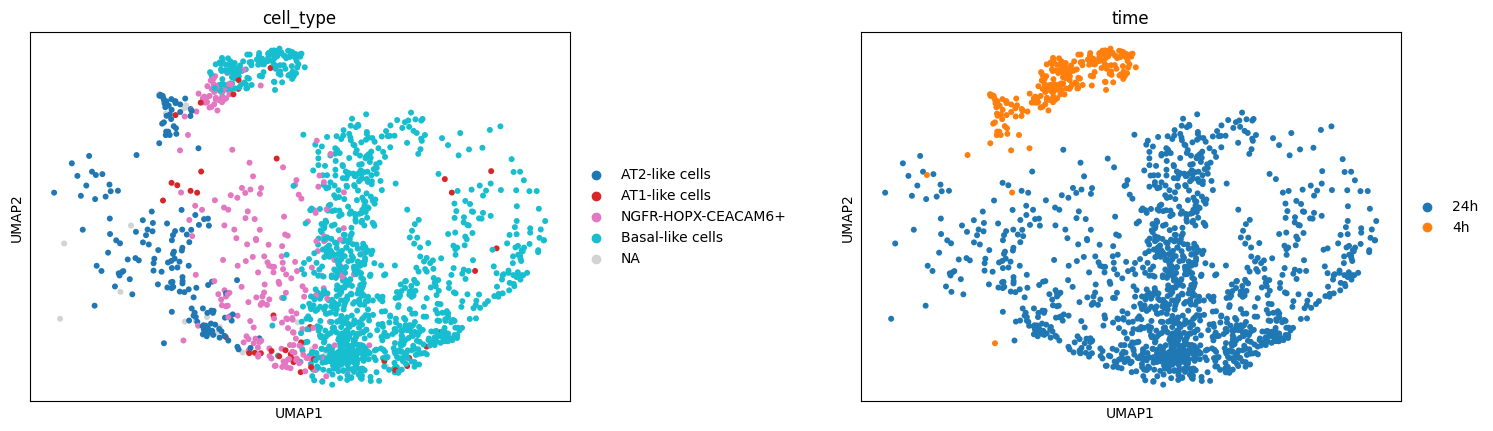

In [23]:
# Plot cell type and time
sc.pl.umap(
    adata_uninf,
    color=["cell_type", "time"],
    wspace=0.4
)

# 03 - Global Infection Response Under RMC-113

To assess infection response under treatment, infected and uninfected cells are compared
within each timepoint under RMC-113 treatment.

## 03A - Early Infection Response (4h, RMC-113)

In [24]:
# Create 4h RMC subset
adata_4h_rmc = adata_qc[
    adata_qc.obs["ID"].isin([
        "4h_infected_RMC-113",
        "4h_uninfected_RMC-113"
    ])
].copy()

In [25]:
# Check groups
adata_4h_rmc.obs["ID"].value_counts()

ID
4h_uninfected_RMC-113    313
4h_infected_RMC-113      226
Name: count, dtype: int64

In [26]:
# Create infection label
adata_4h_rmc.obs["infection"] = adata_4h_rmc.obs["ID"].apply(
    lambda x: "uninfected" if "uninfected" in x else "infected"
)

In [27]:
# Check groups
adata_4h_rmc.obs["infection"].value_counts()

infection
uninfected    313
infected      226
Name: count, dtype: int64

In [28]:
# Run DE
sc.tl.rank_genes_groups(
    adata_4h_rmc,
    groupby="infection",
    method="wilcoxon"
)

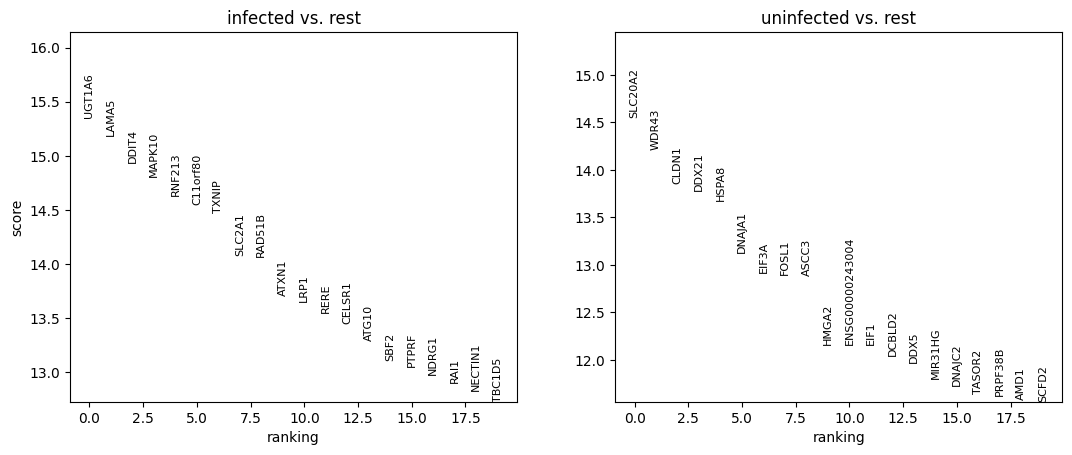

In [29]:
# Plot ranked genes
sc.pl.rank_genes_groups(
    adata_4h_rmc,
    n_genes=20,
    sharey=False
)

## 03B - Late Infection Response (24h, RMC-113)

In [30]:
# Create 24h RMC subset
adata_24h_rmc = adata_qc[
    adata_qc.obs["ID"].isin([
        "24h_infected_RMC-113",
        "24h_uninfected_RMC-113"
    ])
].copy()

In [31]:
# Check groups
adata_24h_rmc.obs["ID"].value_counts()

ID
24h_infected_RMC-113      7488
24h_uninfected_RMC-113    1811
Name: count, dtype: int64

In [32]:
# Create infection label
adata_24h_rmc.obs["infection"] = adata_24h_rmc.obs["ID"].apply(
    lambda x: "uninfected" if "uninfected" in x else "infected"
)

In [33]:
# Check groups
adata_24h_rmc.obs["infection"].value_counts()

infection
infected      7488
uninfected    1811
Name: count, dtype: int64

In [34]:
# Run DE
sc.tl.rank_genes_groups(
    adata_24h_rmc,
    groupby="infection",
    method="wilcoxon"
)

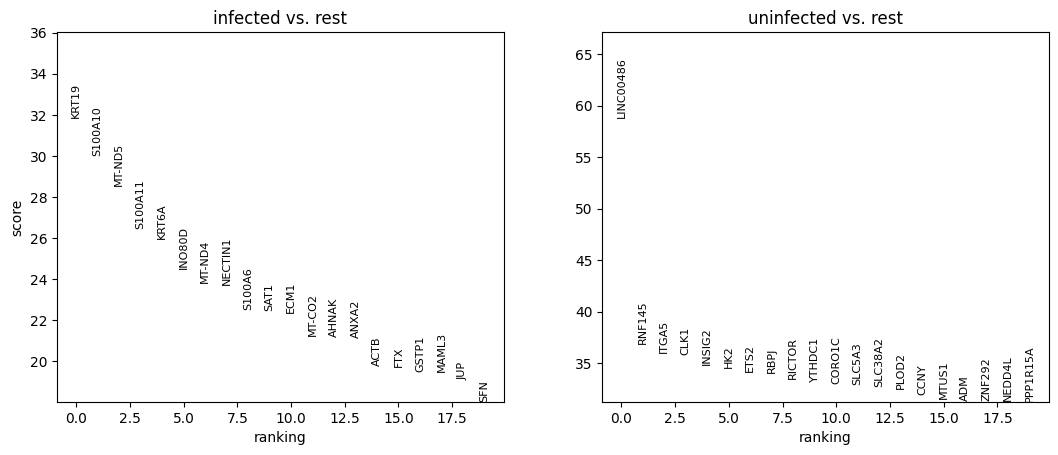

In [35]:
# Plot ranked genes
sc.pl.rank_genes_groups(
    adata_24h_rmc,
    n_genes=20,
    sharey=False
)

# 04 - Cell-Type Specific Infection Response at 4h

Infection response is analyzed within each author-provided cell type at 4h.

In [36]:
# Create 4h DMSO subset
adata_4h_ct = adata_qc[
    adata_qc.obs["ID"].isin([
        "4h_infected_DMSO",
        "4h_uninfected_DMSO"
    ])
].copy()

In [37]:
# Check groups
adata_4h_ct.obs["ID"].value_counts()

ID
4h_uninfected_DMSO    250
4h_infected_DMSO      126
Name: count, dtype: int64

In [38]:
# Create infection label
adata_4h_ct.obs["infection"] = adata_4h_ct.obs["ID"].apply(
    lambda x: "uninfected" if "uninfected" in x else "infected"
)

In [39]:
# check groups
adata_4h_ct.obs["infection"].value_counts()

infection
uninfected    250
infected      126
Name: count, dtype: int64

In [40]:
# Check cell counts by cell type
pd.crosstab(
    adata_4h_ct.obs["cell_type"],
    adata_4h_ct.obs["infection"]
)

infection,infected,uninfected
cell_type,,
AT2-like cells,17,39
AT1-like cells,3,6
NGFR-HOPX-CEACAM6+,23,47
Basal-like cells,83,153


In [41]:
# Create Basal-like subset
adata_4h_blc = adata_4h_ct[
    adata_4h_ct.obs["cell_type"] == "Basal-like cells"
].copy()

In [42]:
# Run DE
sc.tl.rank_genes_groups(
    adata_4h_blc,
    groupby="infection",
    method="wilcoxon"
)

In [43]:
# Extract top genes
top_inf_4h_blc = pd.DataFrame(
    adata_4h_blc.uns["rank_genes_groups"]["names"]
)["infected"][:8].tolist()

top_uninf_4h_blc = pd.DataFrame(
    adata_4h_blc.uns["rank_genes_groups"]["names"]
)["uninfected"][:8].tolist()

top_genes_4h_blc = list(dict.fromkeys(top_inf_4h_blc + top_uninf_4h_blc))

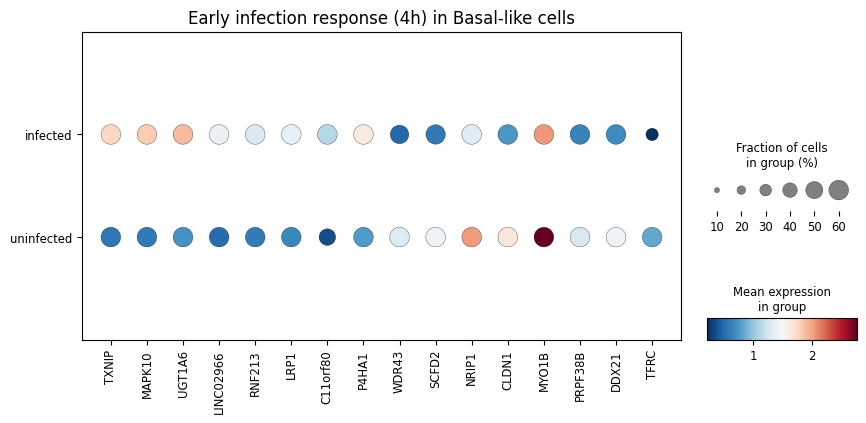

In [44]:
# Plot dotplot
sc.pl.dotplot(
    adata_4h_blc,
    var_names=top_genes_4h_blc,
    groupby="infection",
    cmap="RdBu_r",
    dot_max=0.6,
    figsize=(10, 4),
    title="Early infection response (4h) in Basal-like cells"
)

# 05 - Cell-Type Specific Infection Response at 24h

Infection response is analyzed within each author-provided cell type at 24h.

In [45]:
# Create 24h DMSO subset
adata_24h_ct = adata_qc[
    adata_qc.obs["ID"].isin([
        "24h_infected_DMSO",
        "24h_uninfected_DMSO"
    ])
].copy()

In [46]:
# check groups
adata_24h_ct.obs["ID"].value_counts()

ID
24h_infected_DMSO      8506
24h_uninfected_DMSO    1373
Name: count, dtype: int64

In [47]:
# Create infection label
adata_24h_ct.obs["infection"] = adata_24h_ct.obs["ID"].apply(
    lambda x: "uninfected" if "uninfected" in x else "infected"
)

In [48]:
# check groups
adata_24h_ct.obs["infection"].value_counts()

infection
infected      8506
uninfected    1373
Name: count, dtype: int64

In [49]:
# Check cell counts by cell type
pd.crosstab(
    adata_24h_ct.obs["cell_type"],
    adata_24h_ct.obs["infection"]
)

infection,infected,uninfected
cell_type,,
AT2-like cells,2594,129
AT1-like cells,866,34
NGFR-HOPX-CEACAM6+,0,187
Basal-like cells,5043,1005


In [50]:
# Define cell types
cell_types_24h = [
    "AT2-like cells",
    "AT1-like cells",
    "Basal-like cells",
    "NGFR-HOPX-CEACAM6+"
]

In [51]:
# Run DE by cell type
de_results_24h_ct = {}

for ct in cell_types_24h:
    ad = adata_24h_ct[adata_24h_ct.obs["cell_type"] == ct].copy()

    if ad.n_obs == 0:
        continue

    counts = ad.obs["infection"].value_counts()
    if not {"infected", "uninfected"}.issubset(counts.index):
        continue

    sc.tl.rank_genes_groups(
        ad,
        groupby="infection",
        method="wilcoxon"
    )

    de_results_24h_ct[ct] = ad

In [52]:
# Check which cell types were analyzed

de_results_24h_ct.keys()

dict_keys(['AT2-like cells', 'AT1-like cells', 'Basal-like cells'])

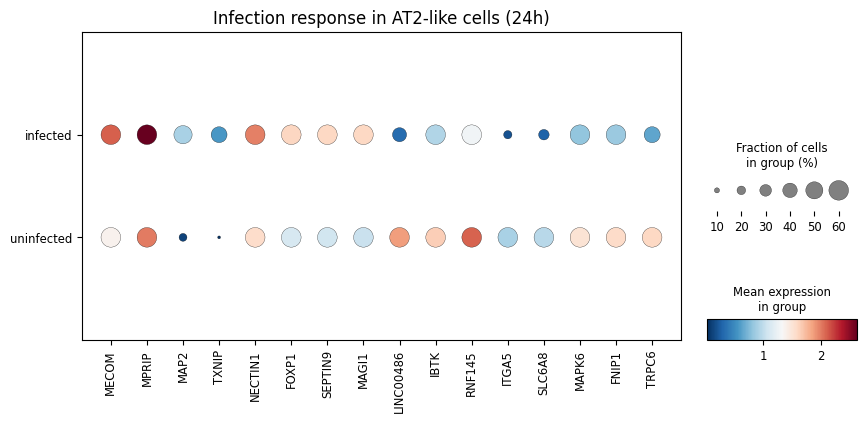

In [53]:
# Extract top genes for infected cells in AT2-like cells
top_infected_basal = pd.DataFrame(
    de_results_24h_ct["AT2-like cells"].uns["rank_genes_groups"]["names"]
)["infected"][:8].tolist()

# Extract top genes for uninfected cells in AT2-like cells
top_uninfected_basal = pd.DataFrame(
    de_results_24h_ct["AT2-like cells"].uns["rank_genes_groups"]["names"]
)["uninfected"][:8].tolist()

# Combine both gene lists and remove duplicates
top_genes_basal = list(dict.fromkeys(top_infected_basal + top_uninfected_basal))

# Plot dotplot for AT2-like cells
sc.pl.dotplot(
    de_results_24h_ct["AT2-like cells"],
    var_names=top_genes_basal,
    groupby="infection",
    cmap="RdBu_r",
    dot_max=0.6,
    figsize=(10,4),
    title="Infection response in AT2-like cells (24h)"
)

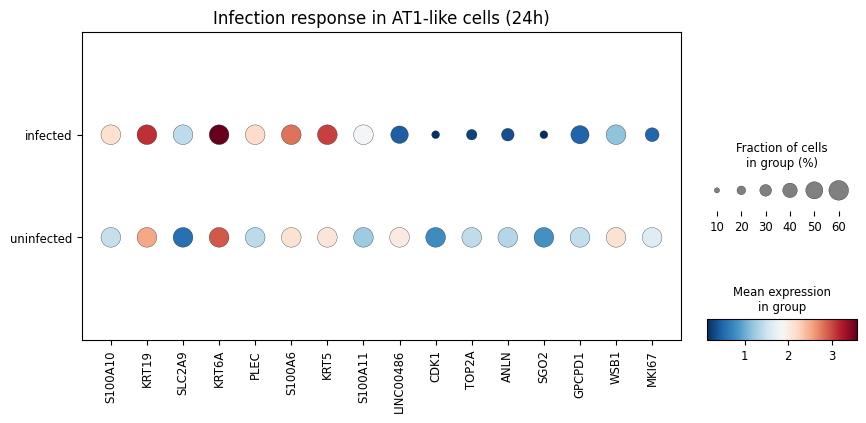

In [54]:
# Extract top genes for infected cells in AT1-like cells
top_infected_basal = pd.DataFrame(
    de_results_24h_ct["AT1-like cells"].uns["rank_genes_groups"]["names"]
)["infected"][:8].tolist()

# Extract top genes for uninfected cells in AT1-like cells
top_uninfected_basal = pd.DataFrame(
    de_results_24h_ct["AT1-like cells"].uns["rank_genes_groups"]["names"]
)["uninfected"][:8].tolist()

# Combine both gene lists and remove duplicates
top_genes_basal = list(dict.fromkeys(top_infected_basal + top_uninfected_basal))

# Plot dotplot for AT1-like cells
sc.pl.dotplot(
    de_results_24h_ct["AT1-like cells"],
    var_names=top_genes_basal,
    groupby="infection",
    cmap="RdBu_r",
    dot_max=0.6,
    figsize=(10,4),
    title="Infection response in AT1-like cells (24h)"
)

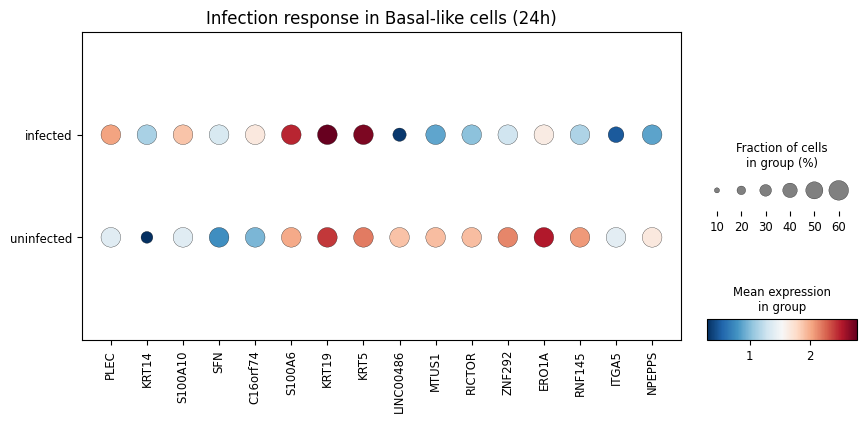

In [55]:
# Extract top genes for infected cells in Basal-like cells
top_infected_basal = pd.DataFrame(
    de_results_24h_ct["Basal-like cells"].uns["rank_genes_groups"]["names"]
)["infected"][:8].tolist()

# Extract top genes for uninfected cells in Basal-like cells
top_uninfected_basal = pd.DataFrame(
    de_results_24h_ct["Basal-like cells"].uns["rank_genes_groups"]["names"]
)["uninfected"][:8].tolist()

# Combine both gene lists and remove duplicates
top_genes_basal = list(dict.fromkeys(top_infected_basal + top_uninfected_basal))

# Plot dotplot for Basal-like cells
sc.pl.dotplot(
    de_results_24h_ct["Basal-like cells"],
    var_names=top_genes_basal,
    groupby="infection",
    cmap="RdBu_r",
    dot_max=0.6,
    figsize=(10,4),
    title="Infection response in Basal-like cells (24h)"
)

# 06 - Infection Response Summary Across Cell Types (24h)

Top infection-responsive genes from each 24h cell type are combined into a summary plot.

In [56]:
# Collect top genes
top_genes_24h_ct = []

for ct, ad in de_results_24h_ct.items():
    genes = pd.DataFrame(
        ad.uns["rank_genes_groups"]["names"]
    )["infected"][:5].tolist()
    top_genes_24h_ct.extend(genes)

top_genes_24h_ct = list(dict.fromkeys(top_genes_24h_ct))

In [57]:
# remove cells without cell type annotation
adata_24h_ct = adata_24h_ct[~adata_24h_ct.obs["cell_type"].isna()].copy()

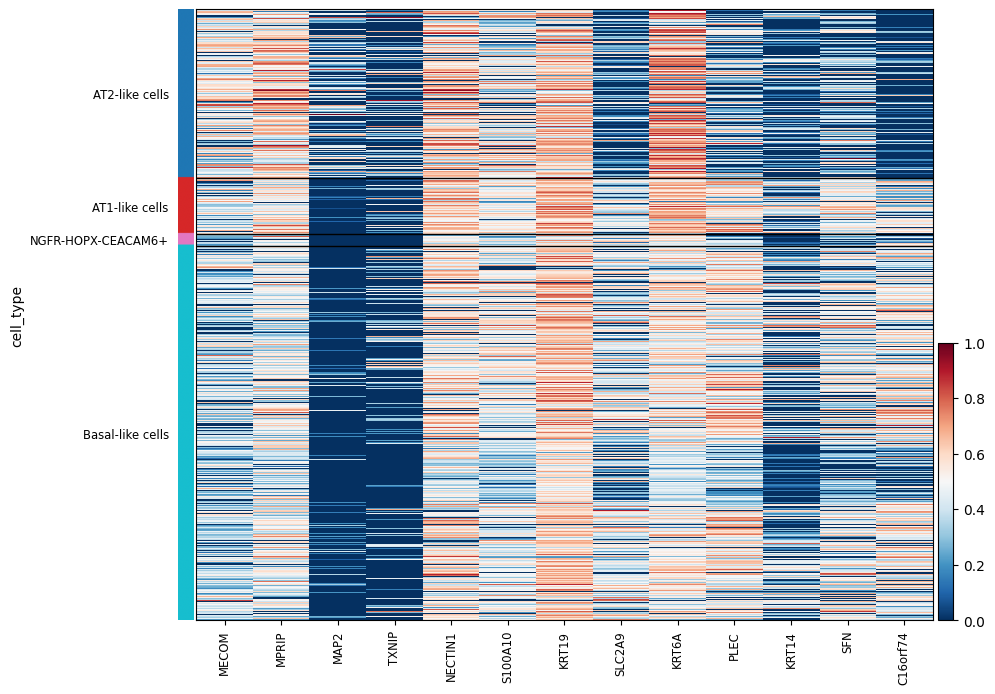

In [58]:
# Plot heatmap
sc.pl.heatmap(
    adata_24h_ct,
    var_names=top_genes_24h_ct,
    groupby="cell_type",
    standard_scale="var",
    cmap="RdBu_r",
    figsize=(10, 8)
)

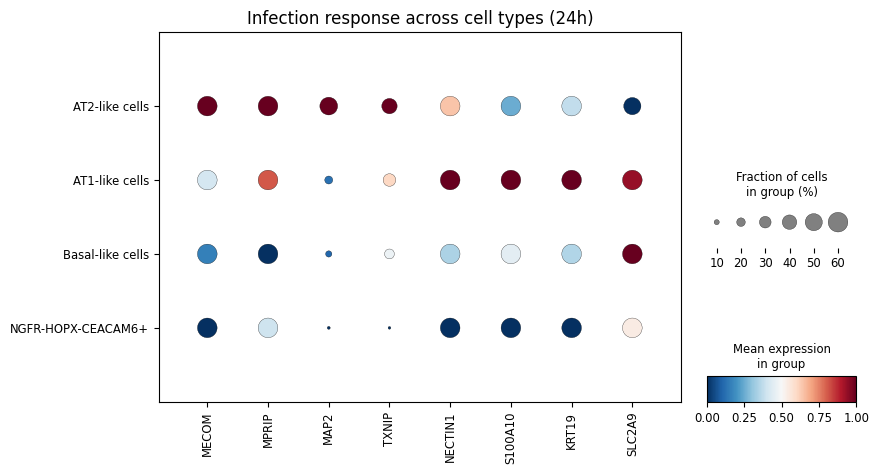

In [59]:
# Plot summary dotplot
adata_24h_ct = adata_24h_ct[~adata_24h_ct.obs["cell_type"].isna()].copy()

sc.pl.dotplot(
    adata_24h_ct,
    var_names=top_genes_24h_ct[:8],
    groupby="cell_type",
    categories_order=[
        "AT2-like cells",
        "AT1-like cells",
        "Basal-like cells",
        "NGFR-HOPX-CEACAM6+"
    ],
    standard_scale="var",
    cmap="RdBu_r",
    dot_max=0.6,
    figsize=(9, 4.8),
    title="Infection response across cell types (24h)",
    show=False
)

plt.savefig("../figures/Figure_11_section_06_celltype_response_24h.png", dpi=300, bbox_inches="tight")
plt.show()

# 07 - Cell-Type Abundance Changes

This analysis evaluates whether infection changes the proportion of author-provided cell types.

In [60]:
# Create infection label globally
adata_qc.obs["infection"] = adata_qc.obs["ID"].apply(
    lambda x: "uninfected" if "uninfected" in x else "infected"
)

In [61]:
# Count cells
celltype_counts = pd.crosstab(
    adata_qc.obs["cell_type"],
    adata_qc.obs["infection"]
)

celltype_counts

infection,infected,uninfected
cell_type,,
AT2-like cells,5019,447
AT1-like cells,1455,84
NGFR-HOPX-CEACAM6+,59,551
Basal-like cells,9804,2632


In [62]:
# Convert to proportions
celltype_props = celltype_counts.div(celltype_counts.sum(axis=0), axis=1)

celltype_props

infection,infected,uninfected
cell_type,,
AT2-like cells,0.307217,0.120355
AT1-like cells,0.089062,0.022617
NGFR-HOPX-CEACAM6+,0.003611,0.148358
Basal-like cells,0.600110,0.708670


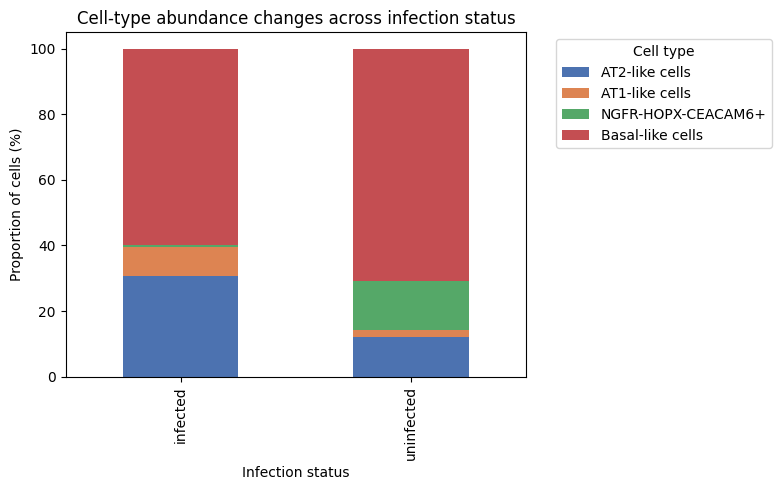

In [63]:
# Convert to percentage
celltype_props_plot = celltype_props * 100

# Plot stacked bars
ax = celltype_props_plot.T.plot(
    kind="bar",
    stacked=True,
    figsize=(8, 5),
    color=["#4C72B0", "#DD8452", "#55A868", "#C44E52"]
)

plt.ylabel("Proportion of cells (%)")
plt.xlabel("Infection status")
plt.title("Cell-type abundance changes across infection status")
plt.legend(title="Cell type", bbox_to_anchor=(1.05, 1), loc="upper left")


plt.tight_layout()
plt.savefig("../figures/Figure_12_section_07_celltype_abundance.png", dpi=300, bbox_inches="tight")
plt.show()

# 08 - Drug Effect on Infection Pathways

Infected cells treated with RMC-113 are compared with infected cells treated with DMSO at 24h.

In [64]:
# Create infected 24h subset
adata_drug_24h = adata_qc[
    adata_qc.obs["ID"].isin([
        "24h_infected_DMSO",
        "24h_infected_RMC-113"
    ])
].copy()

In [65]:
# check groups
adata_drug_24h.obs["ID"].value_counts()

ID
24h_infected_DMSO       8506
24h_infected_RMC-113    7488
Name: count, dtype: int64

In [66]:
# Create treatment label
adata_drug_24h.obs["treatment"] = adata_drug_24h.obs["ID"].apply(
    lambda x: "RMC-113" if "RMC-113" in x else "DMSO"
)

In [67]:
# check groups
adata_drug_24h.obs["treatment"].value_counts()

treatment
DMSO       8506
RMC-113    7488
Name: count, dtype: int64

In [68]:
# Run DE
sc.tl.rank_genes_groups(
    adata_drug_24h,
    groupby="treatment",
    method="wilcoxon"
)

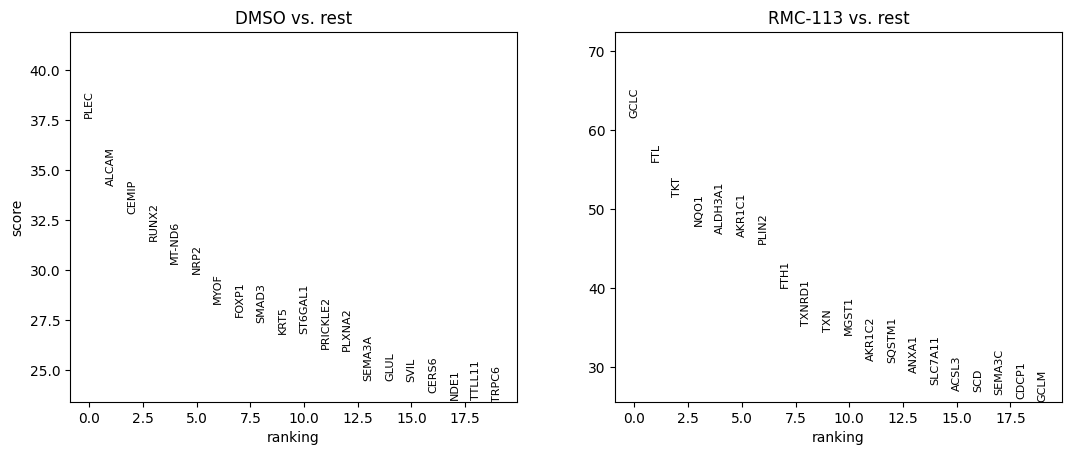

In [69]:
# Plot ranked genes
sc.pl.rank_genes_groups(
    adata_drug_24h,
    n_genes=20,
    sharey=False
)

In [70]:
# Extract top genes
top_rmc_24h = pd.DataFrame(
    adata_drug_24h.uns["rank_genes_groups"]["names"]
)["RMC-113"][:8].tolist()

top_dmso_24h = pd.DataFrame(
    adata_drug_24h.uns["rank_genes_groups"]["names"]
)["DMSO"][:8].tolist()

top_genes_drug_24h = list(dict.fromkeys(top_rmc_24h + top_dmso_24h))

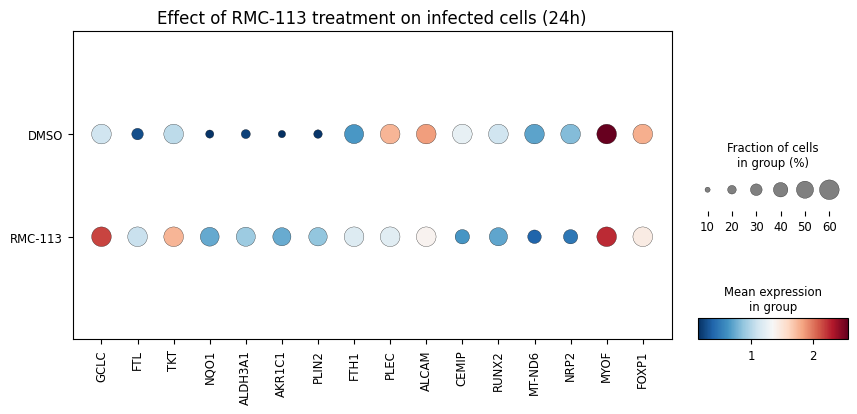

In [71]:
# Plot dotplot
sc.pl.dotplot(
    adata_drug_24h,
    var_names=top_genes_drug_24h,
    groupby="treatment",
    cmap="RdBu_r",
    dot_max=0.6,
    figsize=(10, 4),
    title="Effect of RMC-113 treatment on infected cells (24h)",
    show=False
)

plt.savefig("../figures/Figure_13_section_08_drug_effect_24h.png", dpi=300, bbox_inches="tight")
plt.show()

# Export

In [72]:
de_table = sc.get.rank_genes_groups_df(adata_drug_24h, group="RMC-113")
de_table.to_csv("../results/de_drug_effect_24h.csv", index=False)

## Summary

- Compared infected and uninfected cells under DMSO control at 4h and 24h
  to characterize early and late transcriptional responses to infection
- Evaluated infection response across epithelial cell types, revealing
  cell-type-specific transcriptional patterns
- Assessed cell-type abundance changes between infected and uninfected conditions
- Compared infected cells treated with RMC-113 vs DMSO at 24h to investigate
  treatment-associated transcriptional effects
- Identified sets of differentially expressed genes associated with:
  - infection status
  - timepoint
  - treatment condition

Key results were exported for reproducibility:
`../results/de_drug_effect_24h.csv`

These analyses highlight dynamic and cell-type-specific transcriptional responses
to infection and provide insight into how RMC-113 treatment alters these responses.